Fetching time series from GEE (may take 1–2 minutes)...
  Ascending : 301 points
  Descending: 302 points
  Combined  : 228 matched windows


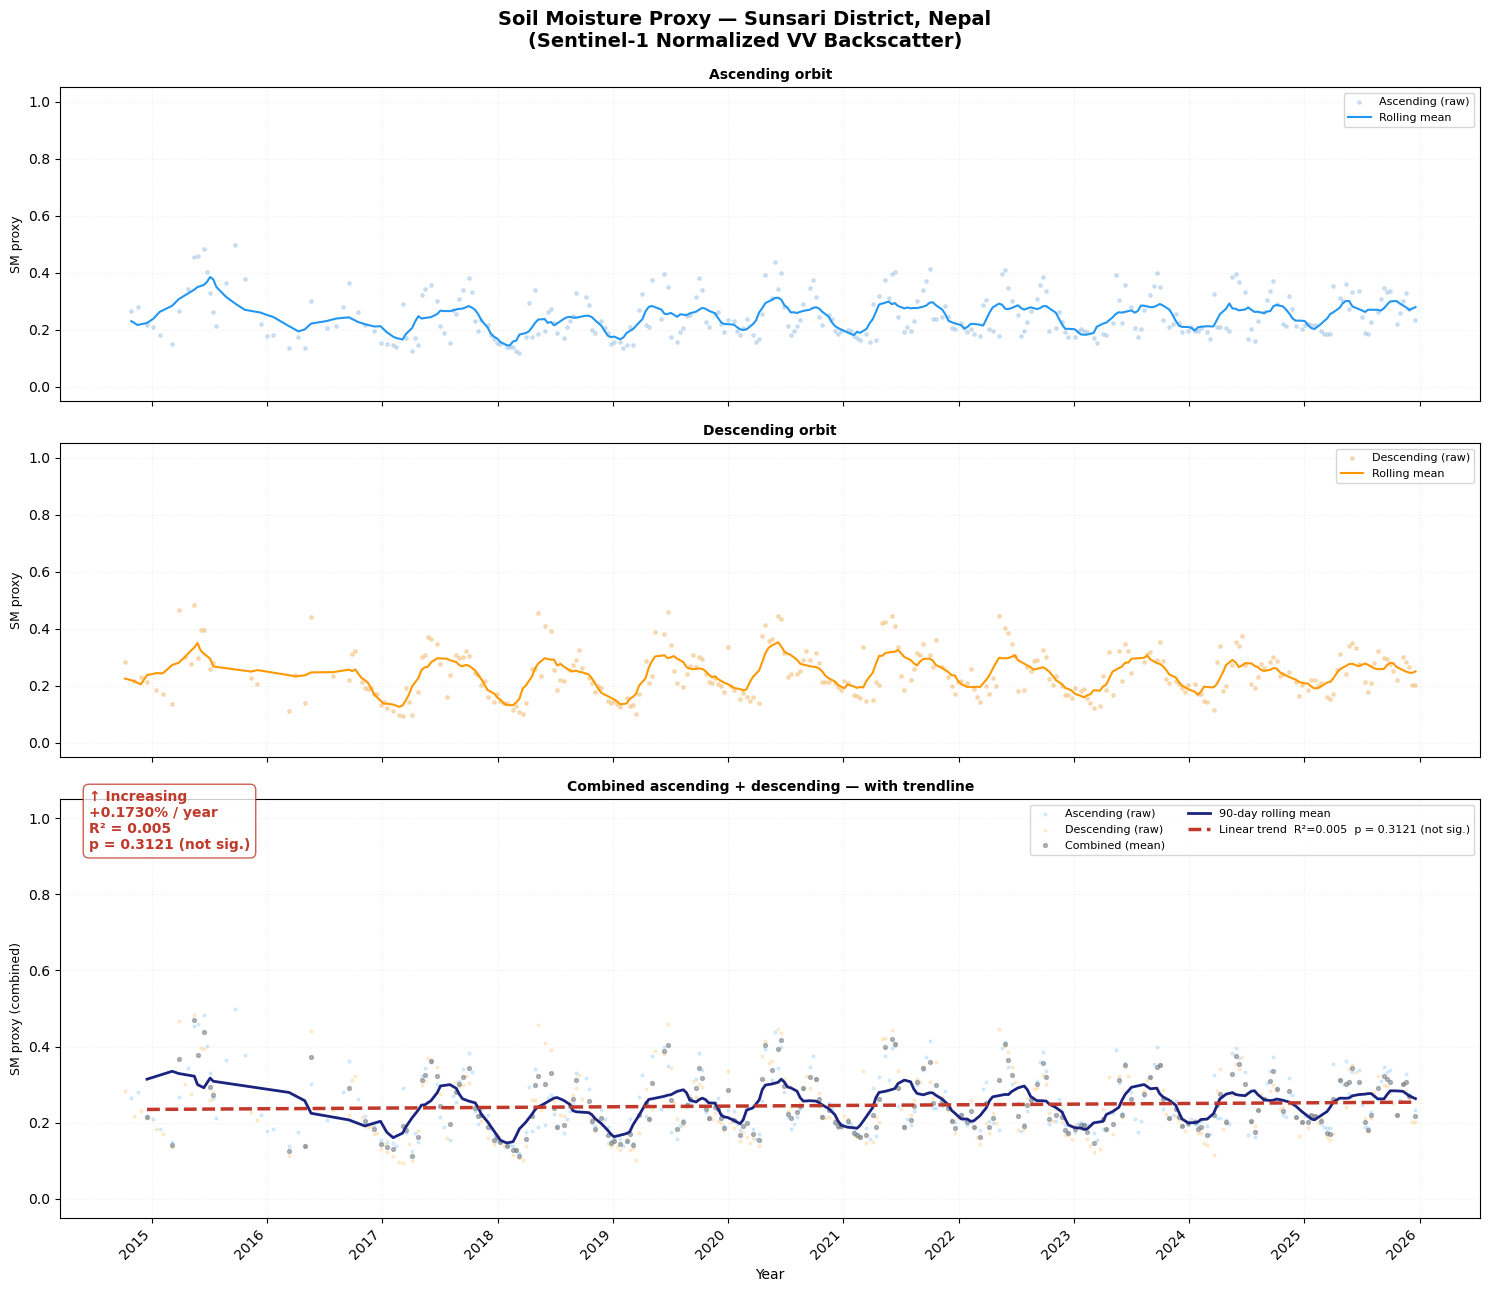


Plot saved → 'sm_combined_trendline.png'

     COMBINED SOIL MOISTURE TREND SUMMARY
  Data range   : 2014-12-17 → 2025-12-19
  Data points  : 228
  Mean SM      : 0.2453
  Annual change: +0.1730% per year
  R²           : 0.0045
  p-value      : 0.312119  →  ⚠️  Not significant (p ≥ 0.05)


In [1]:
"""
Combined Soil Moisture (Ascending + Descending) with Trendline
Sunsari District, Nepal — Sentinel-1 SAR

Requirements:
    pip install earthengine-api numpy pandas matplotlib scipy
"""

import ee
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import linregress
from datetime import datetime

# ─────────────────────────────────────────────
# 1. INITIALIZE
# ─────────────────────────────────────────────
ee.Authenticate()
ee.Initialize(project='injal123')  # ← Replace with your project ID

# ─────────────────────────────────────────────
# 2. DEFINE AREA & TIME RANGE
# ─────────────────────────────────────────────
sunsari = ee.Geometry.Polygon([[
    [87.06, 26.60],
    [87.36, 26.60],
    [87.36, 26.95],
    [87.06, 26.95],
    [87.06, 26.60]
]])

chart_area = ee.Geometry.Rectangle([87.12, 26.70, 87.18, 26.76])

start = ee.Date('2014-01-01')
end   = ee.Date('2025-12-31')

# ─────────────────────────────────────────────
# 3. BUILDS SOIL MOISTURE COLLECTIONS
# ─────────────────────────────────────────────
s1 = (
    ee.ImageCollection("COPERNICUS/S1_GRD")
    .filterDate(start, end)
    .filterBounds(sunsari)
    .filter(ee.Filter.eq('instrumentMode', 'IW'))
    .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV'))
    .select('VV')
)

asc = s1.filter(ee.Filter.eq('orbitProperties_pass', 'ASCENDING'))
des = s1.filter(ee.Filter.eq('orbitProperties_pass', 'DESCENDING'))

# 10-day composites
days      = end.difference(start, 'day')
date_list = ee.List.sequence(0, days, 10).map(lambda d: start.advance(d, 'day'))

def get_ten_day_composite(collection):
    def make_composite(d):
        d         = ee.Date(d)
        composite = collection.filterDate(d, d.advance(10, 'day')).mean()
        return (composite
                .set('system:time_start', d.millis())
                .set('date',              d.format('YYYY-MM-dd'))
                .set('band_count',        composite.bandNames().size()))
    return (ee.ImageCollection(date_list.map(make_composite))
              .filter(ee.Filter.eq('band_count', 1)))

def to_sigma(img):
    sigma   = ee.Image(10).pow(img.divide(10)).rename('sigma')
    speckle = sigma.focalMean(30, 'square', 'meters')
    return speckle.copyProperties(img, img.propertyNames())

# Land mask
dw        = (ee.ImageCollection("GOOGLE/DYNAMICWORLD/V1")
               .filterDate(start, end).filterBounds(sunsari).select('label'))
land_mask = dw.mode().neq(0).And(dw.mode().neq(6))

def normalize(collection):
    col_min = collection.min()
    col_max = collection.max()
    def norm_img(img):
        norm = img.subtract(col_min).divide(col_max.subtract(col_min)).rename('sm')
        return (norm.multiply(land_mask)
                    .copyProperties(img, ['system:time_start'])
                    .set('date', img.get('date')))
    return collection.map(norm_img)

asc_sm = normalize(get_ten_day_composite(asc).map(to_sigma))
des_sm = normalize(get_ten_day_composite(des).map(to_sigma))

# ─────────────────────────────────────────────
# 4. EXTRACT TIME SERIES
# ─────────────────────────────────────────────
def extract_ts(collection):
    def get_mean(img):
        val = img.reduceRegion(
            reducer   = ee.Reducer.mean(),
            geometry  = chart_area,
            scale     = 30,
            maxPixels = 1e9
        )
        return ee.Feature(None, {'date': img.get('date'), 'sm': val.get('sm')})
    return ee.FeatureCollection(collection.map(get_mean))

print("Fetching time series from GEE (may take 1–2 minutes)...")
asc_raw = extract_ts(asc_sm).toList(10000).getInfo()
des_raw = extract_ts(des_sm).toList(10000).getInfo()

def to_dataframe(fc):
    rows = [f['properties'] for f in fc if f['properties'].get('sm') is not None]
    df   = pd.DataFrame(rows)
    df['date'] = pd.to_datetime(df['date'])
    return df.dropna(subset=['sm']).sort_values('date').reset_index(drop=True)

df_asc = to_dataframe(asc_raw)
df_des = to_dataframe(des_raw)
print(f"  Ascending : {len(df_asc)} points")
print(f"  Descending: {len(df_des)} points")

# ─────────────────────────────────────────────
# 5. COMBINE: AVERAGE ON MATCHING DATES
#    Strategy: round each date to its 10-day
#    window label, then average asc + des values
#    that fall in the same window.
# ─────────────────────────────────────────────
def snap_to_window(df):
    """Round each date down to the nearest 10-day window start."""
    origin = pd.Timestamp('2014-01-01')
    days   = (df['date'] - origin).dt.days
    df     = df.copy()
    df['window'] = origin + pd.to_timedelta((days // 10) * 10, unit='D')
    return df

df_asc_w = snap_to_window(df_asc).groupby('window')['sm'].mean().reset_index()
df_des_w = snap_to_window(df_des).groupby('window')['sm'].mean().reset_index()

# Merge on window, keep only dates where BOTH passes exist
df_merged = pd.merge(
    df_asc_w.rename(columns={'sm': 'sm_asc'}),
    df_des_w.rename(columns={'sm': 'sm_des'}),
    on='window', how='inner'
)

# Combined SM = mean of the two passes
df_merged['sm_combined'] = (df_merged['sm_asc'] + df_merged['sm_des']) / 2
df_merged = df_merged.rename(columns={'window': 'date'})

print(f"  Combined  : {len(df_merged)} matched windows")

# ─────────────────────────────────────────────
# 6. TRENDLINE & ROLLING MEAN
# ─────────────────────────────────────────────
def compute_trend(df, col='sm_combined'):
    x      = (df['date'] - df['date'].min()).dt.days.values
    y      = df[col].values
    slope, intercept, r, p, _ = linregress(x, y)
    trend  = intercept + slope * x
    annual = slope * 365
    r2     = r ** 2
    return trend, slope, annual, r2, p

trend_vals, slope, annual, r2, p = compute_trend(df_merged)

# 90-day rolling mean (~9 windows of 10 days)
df_merged['rolling'] = (df_merged['sm_combined']
                          .rolling(window=9, center=True, min_periods=3)
                          .mean())

# ─────────────────────────────────────────────
# 7. PLOT
# ─────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(15, 13), sharex=True,
                         gridspec_kw={'height_ratios': [1.2, 1.2, 1.6]})

fig.suptitle('Soil Moisture Proxy — Sunsari District, Nepal\n'
             '(Sentinel-1 Normalized VV Backscatter)',
             fontsize=14, fontweight='bold', y=0.99)

# ── Panel 1: Ascending only ──────────────────
ax1 = axes[0]
ax1.scatter(df_asc['date'], df_asc['sm'],
            color='#a8c8e8', s=6, alpha=0.5, label='Ascending (raw)')
ax1.plot(df_asc['date'],
         df_asc['sm'].rolling(9, center=True, min_periods=3).mean(),
         color='#2196F3', linewidth=1.5, label='Rolling mean')
ax1.set_ylabel('SM proxy', fontsize=9)
ax1.set_title('Ascending orbit', fontsize=10, fontweight='bold')
ax1.legend(fontsize=8, loc='upper right')
ax1.grid(True, alpha=0.2, linestyle=':')
ax1.set_ylim(-0.05, 1.05)

# ── Panel 2: Descending only ─────────────────
ax2 = axes[1]
ax2.scatter(df_des['date'], df_des['sm'],
            color='#f4c07a', s=6, alpha=0.5, label='Descending (raw)')
ax2.plot(df_des['date'],
         df_des['sm'].rolling(9, center=True, min_periods=3).mean(),
         color='#FF9800', linewidth=1.5, label='Rolling mean')
ax2.set_ylabel('SM proxy', fontsize=9)
ax2.set_title('Descending orbit', fontsize=10, fontweight='bold')
ax2.legend(fontsize=8, loc='upper right')
ax2.grid(True, alpha=0.2, linestyle=':')
ax2.set_ylim(-0.05, 1.05)

# ── Panel 3: Combined + trendline ────────────
ax3 = axes[2]

# Individual passes (faint background)
ax3.scatter(df_asc['date'], df_asc['sm'],
            color='#2196F3', s=4, alpha=0.15, label='Ascending (raw)')
ax3.scatter(df_des['date'], df_des['sm'],
            color='#FF9800', s=4, alpha=0.15, label='Descending (raw)')

# Combined SM
ax3.scatter(df_merged['date'], df_merged['sm_combined'],
            color='#6c757d', s=8, alpha=0.5, zorder=3, label='Combined (mean)')

# Rolling mean
ax3.plot(df_merged['date'], df_merged['rolling'],
         color='#1a237e', linewidth=2, zorder=4, label='90-day rolling mean')

# Trendline
direction = "↑ Increasing" if annual > 0 else "↓ Decreasing"
sig_label = f"p = {p:.4f} {'✓' if p < 0.05 else '(not sig.)'}"
ax3.plot(df_merged['date'], trend_vals,
         color='#c0392b', linewidth=2.5, linestyle='--', zorder=5,
         label=f'Linear trend  R²={r2:.3f}  {sig_label}')

# Trend annotation box
ax3.annotate(
    f'{direction}\n{annual * 100:+.4f}% / year\nR² = {r2:.3f}\n{sig_label}',
    xy=(0.02, 0.88), xycoords='axes fraction',
    fontsize=10, color='#c0392b', fontweight='bold',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.8, edgecolor='#c0392b')
)

ax3.set_ylabel('SM proxy (combined)', fontsize=9)
ax3.set_title('Combined ascending + descending — with trendline',
              fontsize=10, fontweight='bold')
ax3.set_xlabel('Year', fontsize=10)
ax3.legend(fontsize=8, loc='upper right', ncol=2)
ax3.grid(True, alpha=0.2, linestyle=':')
ax3.set_ylim(-0.05, 1.05)
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax3.xaxis.set_major_locator(mdates.YearLocator())

fig.autofmt_xdate(rotation=45)
plt.tight_layout()

output_path = 'sm_combined_trendline.png'
plt.savefig(output_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"\nPlot saved → '{output_path}'")

# ─────────────────────────────────────────────
# 8. SUMMARY
# ─────────────────────────────────────────────
print("\n" + "=" * 50)
print("     COMBINED SOIL MOISTURE TREND SUMMARY")
print("=" * 50)
print(f"  Data range   : {df_merged['date'].min().date()} → {df_merged['date'].max().date()}")
print(f"  Data points  : {len(df_merged)}")
print(f"  Mean SM      : {df_merged['sm_combined'].mean():.4f}")
print(f"  Annual change: {annual * 100:+.4f}% per year")
print(f"  R²           : {r2:.4f}")
print(f"  p-value      : {p:.6f}  →  "
      f"{'✅ Significant (p < 0.05)' if p < 0.05 else '⚠️  Not significant (p ≥ 0.05)'}")
print("=" * 50)
